<a href="https://colab.research.google.com/github/meenakshi-kay/Orbit-Simulation/blob/main/Orbit_simulation_euler_heun_rk4_leapfrog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [4]:
#using sun and earth for now for simplicity

G= 6.67408e-11

M_star = 1.9891e30
M_planet = 5.9722e24

e = 0.0167
a = 1.496e11

# will test wiht other planets and stars later so variabele section

In [5]:
# estimating orbital period first so timestep can scale with orbit size

T_estimate = (4*(math.pi**2)*(a**3)/(G*M_star))**(0.5)
print("Estimated time period (in days):", T_estimate/(60*60*24))

Estimated time period (in days): 365.2073450064896


In [6]:
# can use any step but easier to do it this way. also any ratio high enough works

# starting with 10000 timesteps per orbit
# small enough to make orbit look smooth without taking forever to run

dt = T_estimate / 10000

# running multiple orbits to see how numerical error builds over time (check convergence)
# will try increasing orbits to see if that affects method accuracy
n_orbits = 5

n_steps = int((T_estimate/dt) * n_orbits) # total number of integration steps

# starting at periapsys(is??) because initial velocity and poaition are easiest to define there
r_peri = a * (1 - e)
initial_pos = np.array([r_peri, 0.0])

#usig vis-a-vis equation to calculate intial velocity (currently at periapsis)
init_vel_magnitude = np.sqrt(G * M_star * ((2/r_peri) - (1/a))) #just magnitude first

# velocity starts perpendicular to radius vector
# gives tangential motion needed for orbit
initial_vel = np.array([0.0, init_vel_magnitude])

In [7]:
# keeping acceleration as separate function so it can be reused later for euler, leapfrog, RK4, etc
def calc_acceleration(pos):
    r = np.linalg.norm(pos)     #current distance from star
    return -G * M_star * pos / r**3       # acceleration points toward centre of attraction


# calculating total mechanical energy at every timestep mainly to check how much numerical error builds up
def total_energy(pos, vel):
    r = np.linalg.norm(pos)   #current distance from star
    speed = np.linalg.norm(vel)   #current velcotiy magnitude (aka speed yay)
    KE = 0.5 * M_planet * speed**2    #kinetic energy = 1/2 mv^2
    PE = -G * M_star * M_planet / r   #gravitational potential energy = -GMm/r
    return KE + PE    #total energy = ke + pe
    #should ideally remain const (energy conservation)

## Starting method definitions

#EULER

In [8]:
# keeping Euler method in its own function easier to compare later

def euler(pos, vel, dt, n_steps):
    positions = []
    energies = []
    times = []

    #making copies so original initial conditions stay unchanged
    #bc python treats lists passed as arguments as pass by reference
    pos = pos.copy()
    vel = vel.copy()

    for i in range(n_steps):
        acc = calc_acceleration(pos)

        pos = pos + vel * dt    #updating position first using current velocity
        vel = vel + acc * dt    #updatig velocity using new acceleration

        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return ( np.array(positions), np.array(energies), np.array(times) )   #converiitng lists to arrays

In [9]:
# storing orbit positions, energies, and times separately for plotting later
euler_positions, euler_energies, euler_times = euler( initial_pos, initial_vel, dt, n_steps )

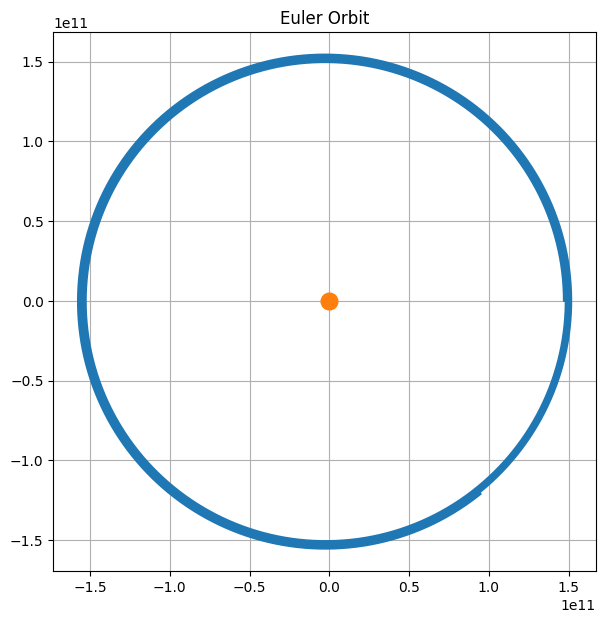

In [10]:
plt.figure(figsize=(7,7))

plt.plot( euler_positions[:,0], euler_positions[:,1] )
plt.plot(0,0, marker='o', markersize=12)

plt.axis('equal')   #setting scales to be equal so the figure doesnt get distorted
plt.title("Euler Orbit")
plt.grid()

plt.show()

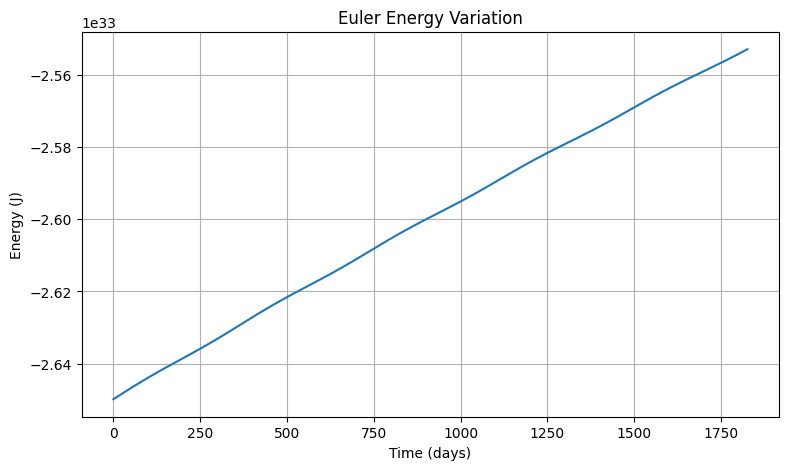

In [11]:
# plotting total energy over time
# ideally this should stay constant if energy is conserved
# any drift here is numerical error from the integration method

plt.figure(figsize=(9,5))

# converting seconds to days so axis labels are easier to read
plt.plot( euler_times/(60*60*24), euler_energies )

plt.xlabel("Time (days)")
plt.ylabel("Energy (J)")

plt.title("Euler Energy Variation")
plt.grid()

plt.show()

#HEUN


In [12]:
# Heun's method is an improved version of Euler's method.
# It first predicts the next position and velocity using Euler's method,
# then corrects that estimate by averaging the initial and predicted slopes.

def heun(pos, vel, dt, n_steps):
    positions = []
    energies = []
    times = []

    # making copies so original initial conditions stay unchanged
    pos = pos.copy()
    vel = vel.copy()

    for i in range(n_steps):

        # acceleration at current position
        acc = calc_acceleration(pos)

        # predictor step using Euler's method
        pos_predict = pos + vel * dt
        vel_predict = vel + acc * dt

        # acceleration at predicted position
        acc_predict = calc_acceleration(pos_predict)

        # corrector step using average velocity and average acceleration
        pos = pos + 0.5 * (vel + vel_predict) * dt
        vel = vel + 0.5 * (acc + acc_predict) * dt

        # storing position, energy and time values
        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return np.array(positions), np.array(energies), np.array(times)

In [19]:
# running Heun simulation
heun_positions, heun_energies, heun_times = heun(initial_pos, initial_vel, dt, n_steps)

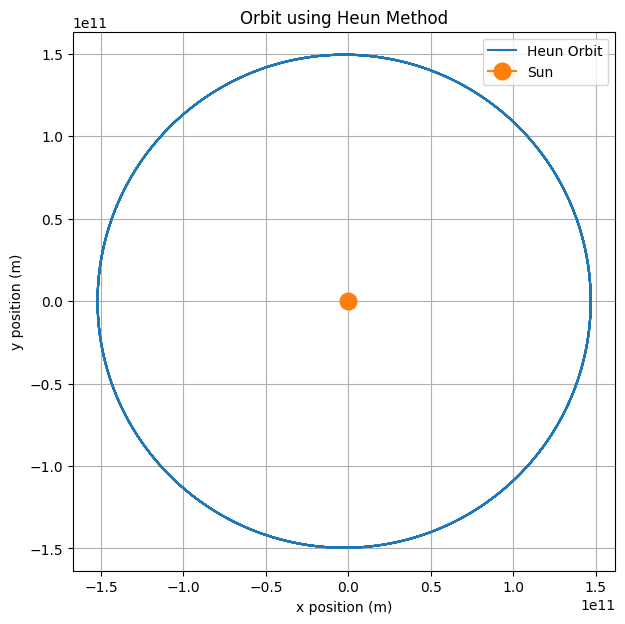

In [20]:
# plotting orbital trajectory using Heun's method

plt.figure(figsize=(7,7))

plt.plot(heun_positions[:,0], heun_positions[:,1], label="Heun Orbit")
plt.plot(0, 0, marker='o', markersize=12, label="Sun")

plt.axis("equal")
plt.title("Orbit using Heun Method")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend()
plt.grid()
plt.show()

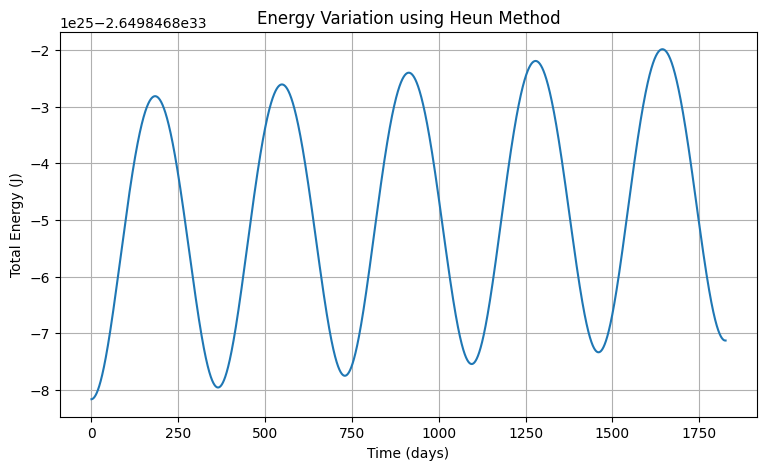

In [21]:
# plotting total energy against time for Heun's method

plt.figure(figsize=(9,5))

plt.plot(heun_times/(60*60*24), heun_energies)

plt.xlabel("Time (days)")
plt.ylabel("Total Energy (J)")
plt.title("Energy Variation using Heun Method")

plt.grid()
plt.show()

#4TH ORDER RUNGE-KUTTA

In [36]:
# Runge-Kutta 4th order method
# RK4 is a higher-order numerical integration method.
# Instead of using only one slope estimate, it calculates four intermediate slopes
# and combines them to get a more accurate update for position and velocity.

def rk4(pos, vel, dt, n_steps):
    positions = []
    energies = []
    times = []

    # making copies so original initial conditions are not changed
    pos = pos.copy()
    vel = vel.copy()

    for i in range(n_steps):

        # k1: slope at the beginning of the interval
        k1_pos = vel
        k1_vel = calc_acceleration(pos)

        # k2: slope at the midpoint using k1 estimate
        k2_pos = vel + 0.5 * k1_vel * dt
        k2_vel = calc_acceleration(pos + 0.5 * k1_pos * dt)

        # k3: slope at the midpoint using k2 estimate
        k3_pos = vel + 0.5 * k2_vel * dt
        k3_vel = calc_acceleration(pos + 0.5 * k2_pos * dt)

        # k4: slope at the end of the interval using k3 estimate
        k4_pos = vel + k3_vel * dt
        k4_vel = calc_acceleration(pos + k3_pos * dt)

        # updating position and velocity using weighted average of slopes
        pos = pos + (dt / 6) * (k1_pos + 2*k2_pos + 2*k3_pos + k4_pos)
        vel = vel + (dt / 6) * (k1_vel + 2*k2_vel + 2*k3_vel + k4_vel)

        # storing values for later plotting
        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return np.array(positions), np.array(energies), np.array(times)

In [37]:
# running RK4 simulation

rk4_positions, rk4_energies, rk4_times = rk4(initial_pos, initial_vel, dt, n_steps)

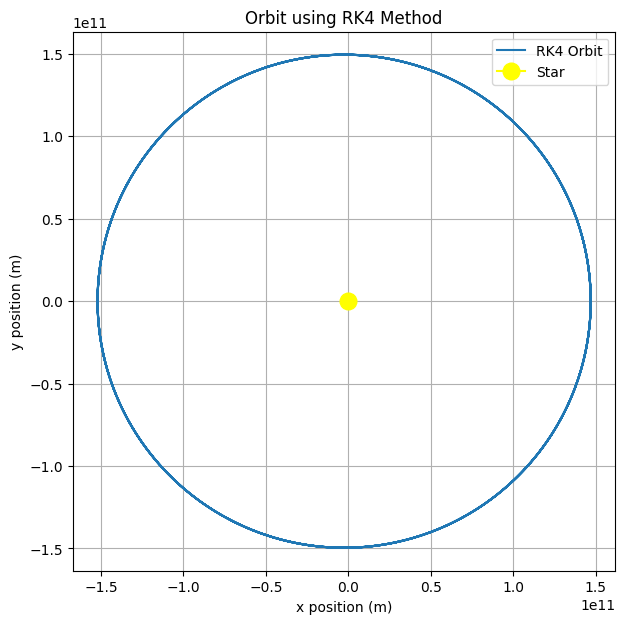

In [38]:
# plotting orbital trajectory using RK4 method

plt.figure(figsize=(7,7))

plt.plot(
    rk4_positions[:,0],
    rk4_positions[:,1],
    label="RK4 Orbit"
)

plt.plot(
    0,
    0,
    marker='o',
    markersize=12,
    label="Star",
    color='yellow'
)

plt.axis("equal")
plt.title("Orbit using RK4 Method")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend()
plt.grid()

plt.show()

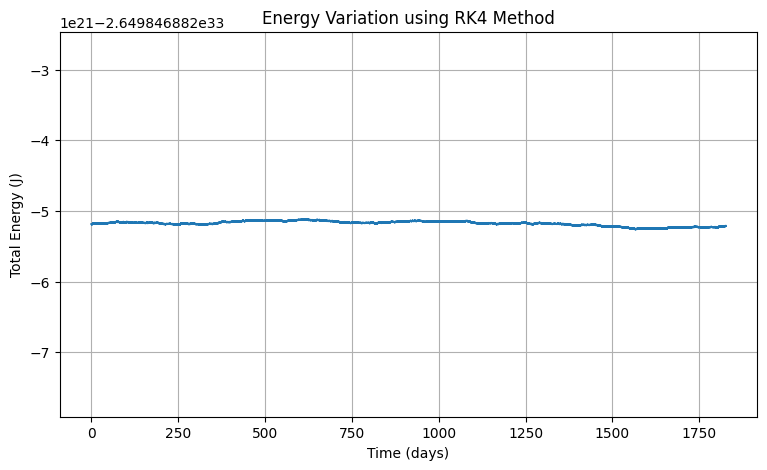

In [39]:
# plotting total energy against time for RK4 method
# a nearly constant energy curve indicates good numerical stability

plt.figure(figsize=(9,5))

plt.plot(
    rk4_times/(60*60*24),
    rk4_energies
)

plt.xlabel("Time (days)")
plt.ylabel("Total Energy (J)")
plt.title("Energy Variation using RK4 Method")

plt.grid()

plt.show()

#LEAPFROG

In [13]:
def run_leapfrog(pos, vel, dt, n_steps):
  # leapfrog splits the velocity update into two halves. one before moving the position and one after
    positions = []
    energies = []
    times = []

    # making copies so original initial conditions dont get mutated
    #(python uses call by reference wheh lists are passed as arguments so any changes wiuld affect eveyr instance of the list)
    pos = pos.copy()
    vel = vel.copy()

    #starting acceleration at initial postion
    #leapforgg always needs acceleration from the current position
    acc = calc_acceleration(pos)

    for i in range(n_steps):

        #first updating velocity by half a timestep. leapfrog staggers posutiton and velocity updates
        #so velocity is "half a step ahead" of pos
        vel_half = vel + 0.5 * acc * dt

        # updating position using the half-step velocity. moves planet to its nect postiosn
        pos = pos + vel_half * dt

        # position changes so gravity also changes so calc new acceleeration
        new_acc = calc_acceleration(pos)

        # second half of the velocity update.n ow velocity has advanced by one full timestep
        vel = vel_half + 0.5 * new_acc * dt

        #storing new acceleration
        acc = new_acc

        # stroing position,energy, time values to plot later
        positions.append(pos.copy())
        energies.append(total_energy(pos, vel))
        times.append(i * dt)

    return (np.array(positions), np.array(energies), np.array(times))

In [14]:
# running leapfrog simulation
leapfrog_positions, leapfrog_energies, leapfrog_times = run_leapfrog(initial_pos,initial_vel,dt,n_steps)

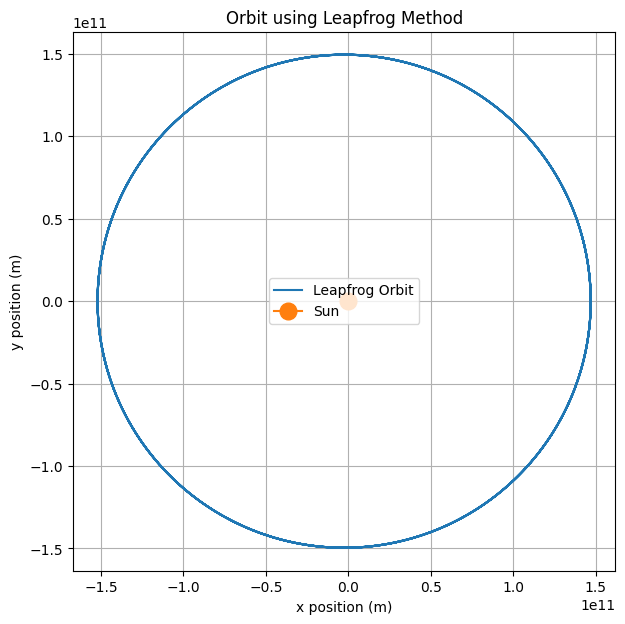

In [15]:
# plotting orbital trajectory, sun is fixed at origin bc assuming  two-body system

plt.figure(figsize=(7,7))

plt.plot(leapfrog_positions[:,0], leapfrog_positions[:,1], label="Leapfrog Orbit" )

plt.plot(0,0, marker='o', markersize=12, label="Sun")

# keeping both axes on same scale so orbit shape isnt distorted
plt.axis('equal')
plt.title("Orbit using Leapfrog Method")

plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend()
plt.grid()

plt.show()

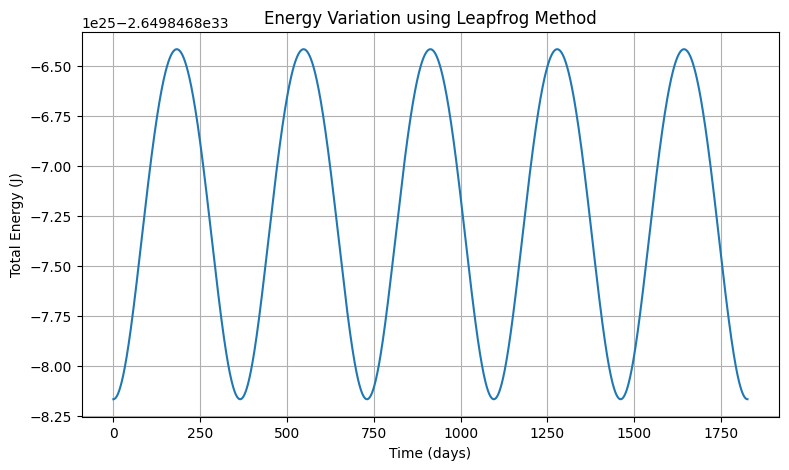

In [16]:
# plotting total energy against time
# ideally this should remain nearly constant throughout
# comparing this later with euler

plt.figure(figsize=(9,5))

plt.plot(leapfrog_times/(60*60*24), leapfrog_energies)

plt.xlabel("Time (days)")
plt.ylabel("Total Energy (J)")

plt.title("Energy Variation using Leapfrog Method")
plt.grid()

plt.show()

#ENERGY CONSERVATION PLOTS

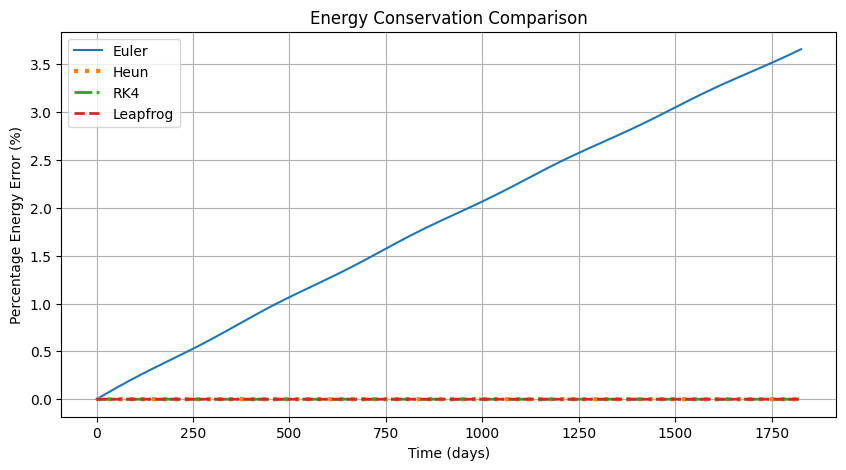

In [40]:
# converting energy drift into percentage error
# easier to compare this way bc absolute energy values are huge

# using the initial energy as the reference value

euler_error = ((euler_energies - euler_energies[0]) / abs(euler_energies[0])) * 100
heun_error = ((heun_energies - heun_energies[0]) / abs(heun_energies[0])) * 100
rk4_error = ((rk4_energies - rk4_energies[0]) / abs(rk4_energies[0])) * 100
leapfrog_error = ((leapfrog_energies - leapfrog_energies[0]) / abs(leapfrog_energies[0])) * 100

plt.figure(figsize=(10,5))

# plotting percentage energy error against time
# lower error means better energy conservation which means better long-term stability
# ideally should stay as close to zero as possible

plt.plot(euler_times/(60*60*24), euler_error, label="Euler")
plt.plot(heun_times/(60*60*24), heun_error, label="Heun", linestyle=":", linewidth=3)
plt.plot(rk4_times/(60*60*24), rk4_error, label="RK4", linestyle="-.", linewidth=2)
plt.plot(leapfrog_times/(60*60*24), leapfrog_error, label="Leapfrog", linestyle="--", linewidth=2)

plt.xlabel("Time (days)")
plt.ylabel("Percentage Energy Error (%)")
plt.title("Energy Conservation Comparison")
plt.legend()
plt.grid()

plt.show()

In [43]:
print(np.max(np.abs(heun_error - leapfrog_error)))  #difference in errors b/n heun and leapfrog bc difficult to see in plot
print(np.max(np.abs(heun_error - rk4_error)))     #difference in errors b/n heun and rk4
print(np.max(np.abs(leapfrog_error - rk4_error)))     #difference in errors b/n rk4 and leapfrog

1.6726778125370702e-06
2.333165275981591e-06
6.605187899143276e-07


#ORBIT PLOTS

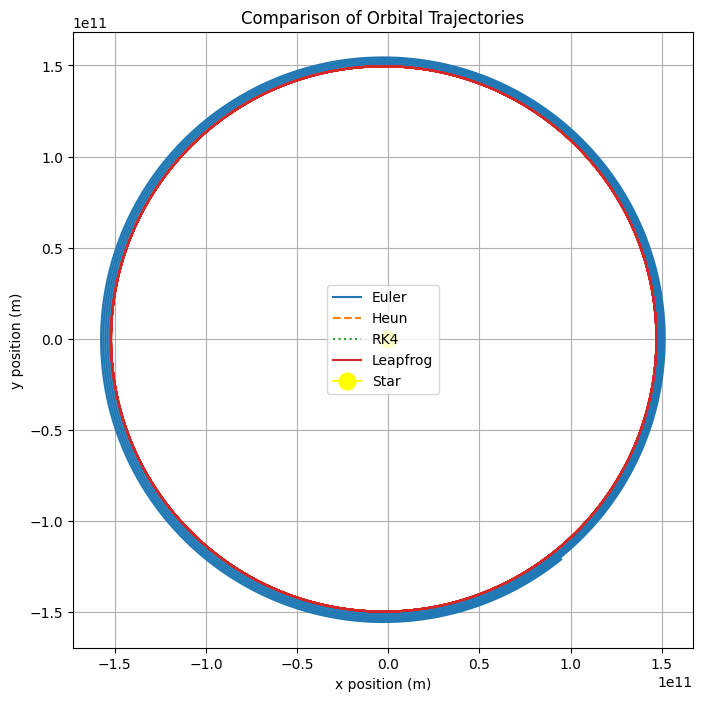

In [44]:
# plotting orbital trajectories obtained using different numerical methods
# placing all methods on the same graph makes it easier to compare how numerical errors affect the orbit shape over time

plt.figure(figsize=(8,8))

plt.plot(
    euler_positions[:,0],
    euler_positions[:,1],
    label="Euler"
)

plt.plot(
    heun_positions[:,0],
    heun_positions[:,1],
    label="Heun",
    linestyle="--"
)

plt.plot(
    rk4_positions[:,0],
    rk4_positions[:,1],
    label="RK4",
    linestyle=":"
)

plt.plot(
    leapfrog_positions[:,0],
    leapfrog_positions[:,1],
    label="Leapfrog"
)

# central star fixed at the origin

plt.plot(
    0,
    0,
    marker='o',
    markersize=12,
    label="Star",
    color='yellow'
)

plt.axis("equal")
plt.title("Comparison of Orbital Trajectories")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")

plt.legend()
plt.grid()

plt.show()

The heun, rk4 and Leapfrog methods produced nearly identical orbits for the chosen timestep. this showws comparable accuracy for this simulation.